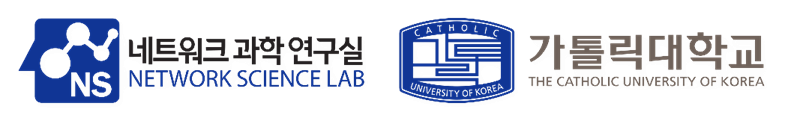

<h1><center><b>💻 Assignment 1:</b> </br>👋 Graph Basics & Node Embeddings!</center></h1>

<a target="_blank" href="https://colab.research.google.com/github/NSLab-CUK/Graph-Neural-Networks-Fall-2026/blob/main/W6/Solution_1.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

> 🌸 **Submission Reminder**
>
> Please make sure to **submit your `.ipynb` (Jupyter Notebook) file along with any additional required files** for grading.
>
> Other formats, such as **PDF files, screenshots, or `.py` files**, cannot be accepted as substitutes for the required Jupyter Notebook.
>
> Please also ensure that your submitted notebook:
>
> * **Runs without errors**.
> * Contains **executed code cells with visible outputs/results**.
> * Is **not left blank, unrun, or missing required results**.
>
> **Error files, unrun notebooks, blank notebooks, or notebooks without results will not be accepted for grading.**
>
> Thank you, and happy coding! 💻✨



👋 This notebook covers the fundamental concepts of graph construction, visualization, representation, and basic node embedding techniques (Node2Vec and LINE).


## Part 1: Graph Basics with NetworkX

### Exercise 1: Graph Construction and Visualization

**Problem Statement**: 
Given an undirected graph with 10 nodes (0, 1, 2, 3, 4, 5, 6, 7, 8, 9) and the following edge list:
`(0, 1), (0, 4), (1, 2), (1, 3), (2, 5), (3, 4), (4, 6), (5, 7), (6, 8), (7, 9), (8, 9)`

**Guidelines**:
1. Construct the graph using the `networkx` library.
2. Visualize the graph using `matplotlib`.
3. Compute and print the number of nodes and edges in the graph.
4. Extract and print the lists of all nodes and edges.


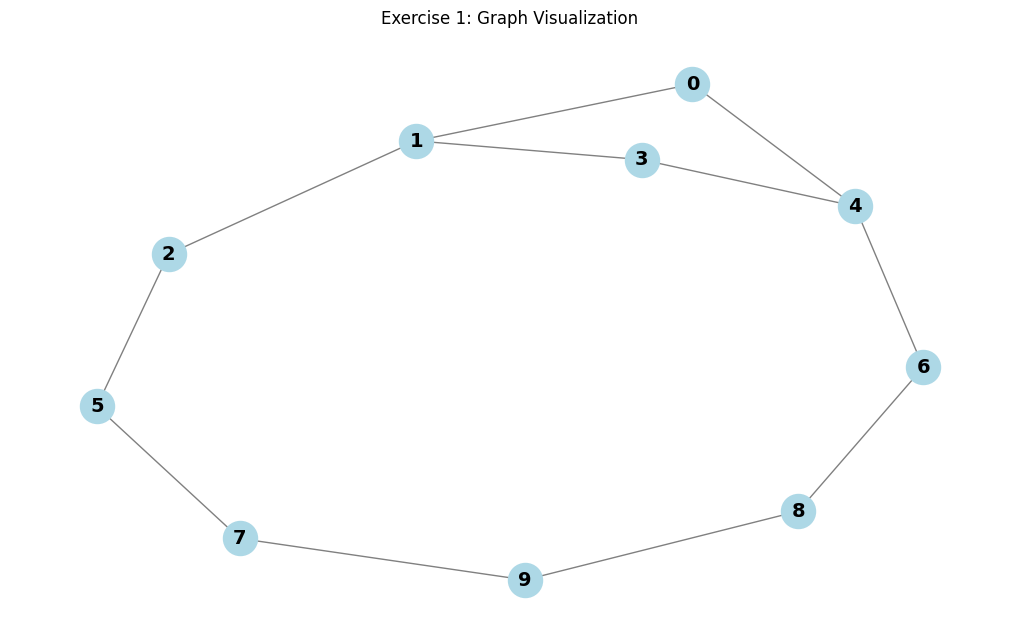

Number of nodes: 10
Number of edges: 11
Nodes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Edges: [(0, 1), (0, 4), (1, 2), (1, 3), (2, 5), (3, 4), (4, 6), (5, 7), (6, 8), (7, 9), (8, 9)]


In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# 1. Define edges and create the graph
edges = [(0, 1), (0, 4), (1, 2), (1, 3), (2, 5), (3, 4), (4, 6), (5, 7), (6, 8), (7, 9), (8, 9)]
G = nx.Graph()
G.add_nodes_from(range(10)) # Ensure all 10 nodes are added, even if isolated
G.add_edges_from(edges)

# 2. Draw the graph
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=600, font_size=14, font_weight='bold', edge_color='gray')
plt.title("Exercise 1: Graph Visualization")
plt.show()

# 3. Count nodes and edges
print(f"Number of nodes: {G.number_of_nodes()}")
print(f"Number of edges: {G.number_of_edges()}")

# 4. List all nodes and edges
print(f"Nodes: {sorted(list(G.nodes()))}")
print(f"Edges: {sorted(list(G.edges()))}")


### Exercise 2: Graph Representations and Node Degrees

**Problem Statement**: 
Given an undirected graph with the following edge set: 
`(1, 2), (1, 4), (2, 3), (2, 5), (3, 6), (4, 5), (4, 7), (5, 6), (5, 8), (6, 9), (7, 8), (8, 9)`

**Guidelines**:
1. Construct and visualize the graph.
2. Extract the **Adjacency Matrix** representation of the graph and print it.
3. Extract the **Edge List** representation and print it.
4. Compute and print the degree of each node.


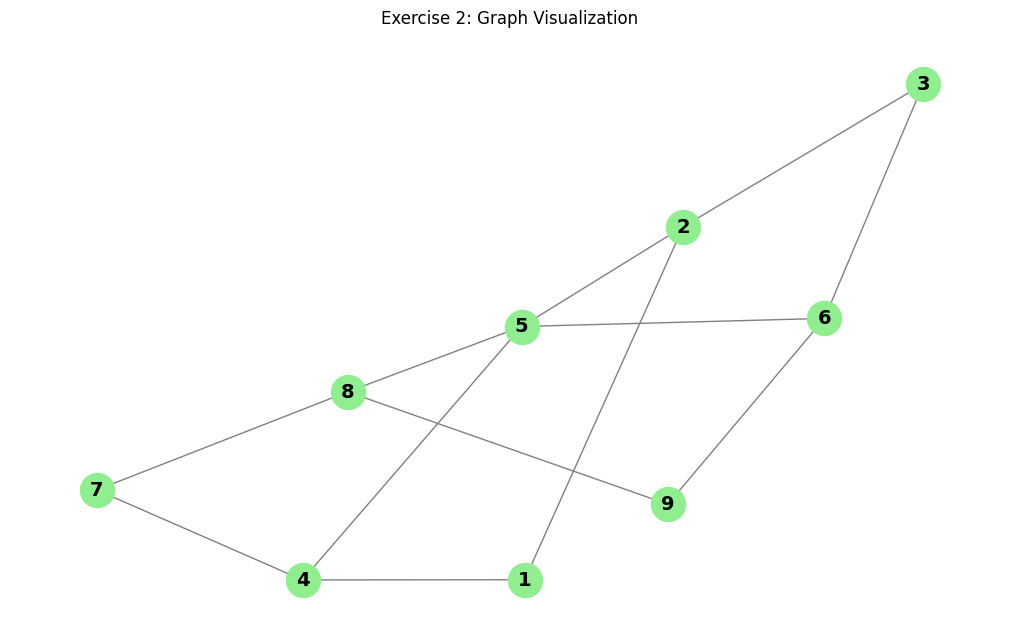

=== Adjacency Matrix ===
     1  2  3  4  5  6  7  8  9
1:   0  1  0  1  0  0  0  0  0
2:   1  0  1  0  1  0  0  0  0
3:   0  1  0  0  0  1  0  0  0
4:   1  0  0  0  1  0  1  0  0
5:   0  1  0  1  0  1  0  1  0
6:   0  0  1  0  1  0  0  0  1
7:   0  0  0  1  0  0  0  1  0
8:   0  0  0  0  1  0  1  0  1
9:   0  0  0  0  0  1  0  1  0

=== Edge List ===
Edge 1: (1, 2)
Edge 2: (1, 4)
Edge 3: (2, 3)
Edge 4: (2, 5)
Edge 5: (3, 6)
Edge 6: (4, 5)
Edge 7: (4, 7)
Edge 8: (5, 6)
Edge 9: (5, 8)
Edge 10: (6, 9)
Edge 11: (7, 8)
Edge 12: (8, 9)

=== Node Degrees ===
Node 1: Degree = 2
Node 2: Degree = 3
Node 3: Degree = 2
Node 4: Degree = 3
Node 5: Degree = 4
Node 6: Degree = 3
Node 7: Degree = 2
Node 8: Degree = 3
Node 9: Degree = 2


In [2]:
# 1. Define edges, create, and visualize the graph
edges_ex2 = [(1, 2), (1, 4), (2, 3), (2, 5), (3, 6), (4, 5), (4, 7), (5, 6), (5, 8), (6, 9), (7, 8), (8, 9)]
G2 = nx.Graph()
G2.add_edges_from(edges_ex2)

plt.figure(figsize=(10, 6))
pos2 = nx.spring_layout(G2, seed=100)
nx.draw(G2, pos2, with_labels=True, node_color='lightgreen', node_size=600, font_size=14, font_weight='bold', edge_color='gray')
plt.title("Exercise 2: Graph Visualization")
plt.show()

# 2. Adjacency Matrix
print("=== Adjacency Matrix ===")
nodes = sorted(list(G2.nodes()))
adj_matrix = nx.adjacency_matrix(G2, nodelist=nodes).todense()

# Print matrix with labels for better readability
print("   " + "".join([f"{n:3}" for n in nodes]))
for i, node in enumerate(nodes):
    row_str = "".join([f"{adj_matrix[i, j]:3}" for j in range(len(nodes))])
    print(f"{node}: {row_str}")

# 3. Edge List
print("\n=== Edge List ===")
for idx, edge in enumerate(sorted(list(G2.edges())), 1):
    print(f"Edge {idx}: {edge}")

# 4. Node Degrees
print("\n=== Node Degrees ===")
for node in sorted(G2.nodes()):
    print(f"Node {node}: Degree = {G2.degree[node]}")


## Part 2: Node Embeddings

### Assignment 1: Node2Vec on the Karate Club Graph

**Problem Statement**: 
Implement the Node2Vec algorithm to learn node representations on Zachary's Karate Club network and visualize the embeddings.

**Guidelines**:
1. Load the Karate Club graph using `torch_geometric` and convert it to a `networkx` graph.
2. Implement random walks with biases $p$ (return parameter) and $q$ (in-out parameter).
3. Train a Word2Vec model on the generated random walks to get node embeddings.
4. Reduce the embeddings to 2 dimensions using t-SNE and visualize them, coloring nodes by their class labels.

**References:** https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html

/home/tuonghh/miniconda3/envs/graph/lib/python3.10/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: Could not load this library: /home/tuonghh/miniconda3/envs/graph/lib/python3.10/site-packages/pyg_lib/libpyg.so
  import torch_geometric.typing
/home/tuonghh/miniconda3/envs/graph/lib/python3.10/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /home/tuonghh/miniconda3/envs/graph/lib/python3.10/site-packages/torch_scatter/_scatter_cuda.so
  import torch_geometric.typing
/home/tuonghh/miniconda3/envs/graph/lib/python3.10/site-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: /home/tuonghh/miniconda3/envs/graph/lib/python3.10/site-packages/torch_sparse/_convert_cuda.so
  i

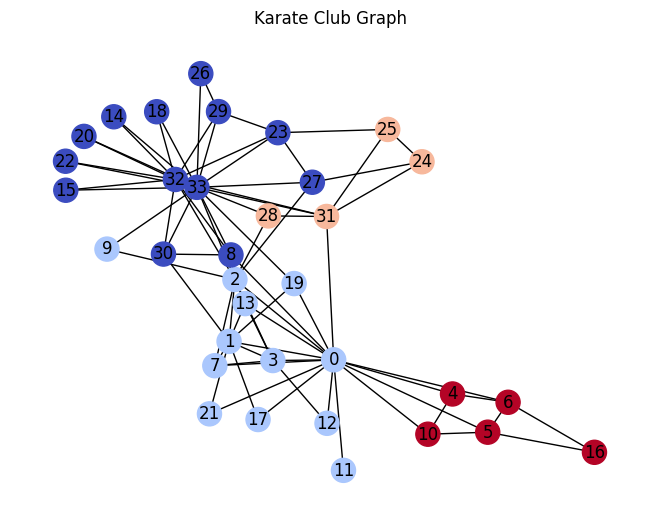

In [3]:
import networkx as nx
import random
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from gensim.models import Word2Vec
from torch_geometric.datasets import KarateClub
from torch_geometric.utils import to_networkx

# 1. Load Karate Club Graph
dataset = KarateClub()[0]
karate_graph = to_networkx(dataset, to_undirected=True)

# Add class attributes to nodes for coloring in visualization
for node in karate_graph.nodes():
    karate_graph.nodes[node]["class"] = int(dataset.y[node])

nx.draw(karate_graph, with_labels=True, node_color=dataset.y.numpy(), cmap='coolwarm')
plt.title("Karate Club Graph")
plt.show()


In [4]:
# 2. Implement Node2Vec Random Walks
def node2vec_weighted_choice(G, current_node, previous_node, p, q):
    neighbors = list(G.neighbors(current_node))
    unnormalized_weights = []

    for neighbor in neighbors:
        if neighbor == previous_node:
            unnormalized_weights.append(1.0 / p)
        elif G.has_edge(previous_node, neighbor):
            unnormalized_weights.append(1.0)
        else:
            unnormalized_weights.append(1.0 / q)

    norm_weights = [w / sum(unnormalized_weights) for w in unnormalized_weights]
    return random.choices(neighbors, weights=norm_weights)[0]

def node2vec_walk(G, start_node, num_steps, p, q):
    walk = [start_node]
    for _ in range(num_steps - 1):
        current_node = walk[-1]
        neighbors = list(G.neighbors(current_node))
        
        if len(neighbors) == 0:
            break
            
        if len(walk) == 1:
            next_node = random.choice(neighbors)
        else:
            next_node = node2vec_weighted_choice(G, current_node, walk[-2], p, q)
            
        walk.append(next_node)
    return walk


In [5]:
# Generate random walks
num_walks = 100
walk_length = 10
p = 0.8
q = 0.2

walks = [
    [str(node) for node in node2vec_walk(
        karate_graph,
        start_node=random.choice(list(karate_graph.nodes())),
        num_steps=walk_length,
        p=p,
        q=q
    )]
    for _ in range(num_walks)
]

# 3. Train Word2Vec Model
node2vec_model = Word2Vec(
    sentences=walks,
    vector_size=128,
    window=5,
    min_count=1,
    sg=1,
    epochs=100
)

# Extract embeddings
node_embeddings = np.array([node2vec_model.wv[str(node)] for node in karate_graph.nodes()])


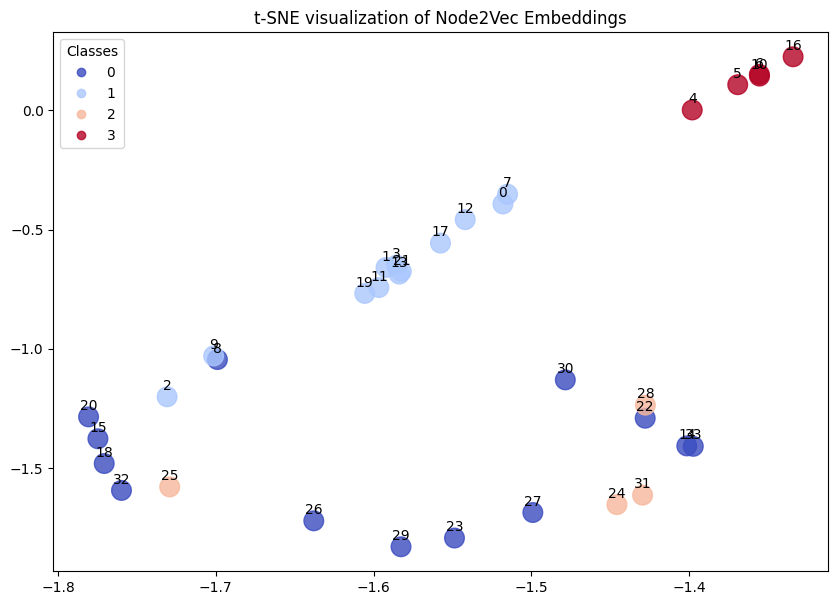

In [6]:
# 4. Visualize with t-SNE
tsne = TSNE(n_components=2, random_state=42)
node_embeddings_2d = tsne.fit_transform(node_embeddings)

labels = [karate_graph.nodes[node]["class"] for node in karate_graph.nodes()]

plt.figure(figsize=(10, 7))
scatter = plt.scatter(node_embeddings_2d[:, 0], node_embeddings_2d[:, 1], c=labels, cmap='coolwarm', s=200, alpha=0.8)

for i, node in enumerate(karate_graph.nodes()):
    plt.annotate(str(node), (node_embeddings_2d[i, 0], node_embeddings_2d[i, 1]), 
                 textcoords="offset points", xytext=(0, 5), ha='center', fontsize=10)

plt.legend(*scatter.legend_elements(), title="Classes")
plt.title("t-SNE visualization of Node2Vec Embeddings")
plt.show()


### Assignment 2: LINE Model on the Karate Club Graph

**Problem Statement**: 
Implement the LINE (Large-scale Information Network Embedding) model to learn representations for each node and visualize the node embeddings via t-SNE.

**Guidelines**:
1. Implement the Vose Alias Method for efficient negative sampling based on node degrees.
2. Define the LINE model in PyTorch, supporting 1st or 2nd order proximity.
3. Train the model on the Karate Club graph.
4. Extract the learned embeddings and visualize them using t-SNE.


In [7]:
import collections
from decimal import Decimal
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1. Vose Alias Method for negative sampling
class VoseAlias:
    def __init__(self, dist):
        self.dist = dist
        self.alias_initialisation()

    def alias_initialisation(self):
        n = len(self.dist)
        self.table_prob = {}
        self.table_alias = {}
        scaled_prob = {}
        small = []
        large = []

        for o, p in self.dist.items():
            scaled_prob[o] = Decimal(p) * n
            if scaled_prob[o] < 1:
                small.append(o)
            else:
                large.append(o)

        while small and large:
            s = small.pop()
            l = large.pop()

            self.table_prob[s] = scaled_prob[s]
            self.table_alias[s] = l
            scaled_prob[l] = (scaled_prob[l] + scaled_prob[s]) - Decimal(1)

            if scaled_prob[l] < 1:
                small.append(l)
            else:
                large.append(l)

        while large:
            self.table_prob[large.pop()] = Decimal(1)
        while small:
            self.table_prob[small.pop()] = Decimal(1)

        self.listprobs = list(self.table_prob)

    def alias_generation(self):
        col = random.choice(self.listprobs)
        if self.table_prob[col] >= random.uniform(0, 1):
            return col
        else:
            return self.table_alias[col]

    def sample_n(self, size):
        for i in range(size):
            yield self.alias_generation()

# Prepare graph distributions for LINE
def makeDist(graph: nx.Graph, power=0.75):
    edgedistdict = collections.defaultdict(int)
    nodedistdict = collections.defaultdict(int)
    
    weightsum = 0
    negprobsum = 0

    for edge in graph.edges(data=True):
        node1, node2, weight = edge[0], edge[1], edge[2].get("weight", 1)
        edgedistdict[tuple([node1, node2])] = weight
        nodedistdict[node1] += weight
        weightsum += weight
        negprobsum += np.power(weight, power)

    for node, outdegree in nodedistdict.items():
        nodedistdict[node] = np.power(outdegree, power) / negprobsum

    for edge, weight in edgedistdict.items():
        edgedistdict[edge] = weight / weightsum

    return nodedistdict

def negSampleBatch(sourcenode, targetnode, negsamplesize, nodesaliassampler):
    negsamples = []
    while len(negsamples) < negsamplesize:
        samplednode = nodesaliassampler.alias_generation()
        if samplednode != sourcenode and samplednode != targetnode:
            negsamples.append(samplednode)
    return torch.tensor(negsamples, dtype=torch.long)


In [8]:
# 2. Define the LINE Model
class LINE(nn.Module):
    def __init__(self, size, embed_dim=128, order=1):
        super(LINE, self).__init__()
        assert order in [1, 2], "Order should either be 1 or 2"
        self.embed_dim = embed_dim
        self.order = order
        
        self.nodes_embeddings = nn.Embedding(size, embed_dim)
        self.nodes_embeddings.weight.data = self.nodes_embeddings.weight.data.uniform_(-.5, .5) / embed_dim

        if order == 2:
            self.contextnodes_embeddings = nn.Embedding(size, embed_dim)
            self.contextnodes_embeddings.weight.data = self.contextnodes_embeddings.weight.data.uniform_(-.5, .5) / embed_dim

    def forward(self, v_i, v_j, negsamples, device):
        v_i = self.nodes_embeddings(v_i).to(device)

        if self.order == 2:
            v_j = self.contextnodes_embeddings(v_j).to(device)
            negativenodes = -self.contextnodes_embeddings(negsamples).to(device)
        else:
            v_j = self.nodes_embeddings(v_j).to(device)
            negativenodes = -self.nodes_embeddings(negsamples).to(device)

        mulpositivebatch = torch.mul(v_i, v_j)
        positivebatch = F.logsigmoid(torch.sum(mulpositivebatch, dim=1))

        mulnegativebatch = torch.mul(v_i.view(len(v_i), 1, self.embed_dim), negativenodes)
        negativebatch = torch.sum(F.logsigmoid(torch.sum(mulnegativebatch, dim=2)), dim=1)
        
        loss = positivebatch + negativebatch
        return -torch.mean(loss)


In [9]:
# 3. Train the model
def train_line(graph, embed_dim=128, epochs=10, neg_samples=5, order=1):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = LINE(size=len(graph.nodes), embed_dim=embed_dim, order=order).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    nodedistdict = makeDist(graph)
    nodesaliassampler = VoseAlias(nodedistdict)

    edges = list(graph.edges())
    
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for v_i, v_j in edges:
            v_i_tensor = torch.tensor([v_i], dtype=torch.long).to(device)
            v_j_tensor = torch.tensor([v_j], dtype=torch.long).to(device)
            neg_samples_batch = negSampleBatch(v_i, v_j, neg_samples, nodesaliassampler).to(device)
            
            optimizer.zero_grad()
            loss = model(v_i_tensor, v_j_tensor, neg_samples_batch, device)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if (epoch + 1) % 2 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(edges):.4f}")

    return model

# Train LINE model on Karate Club graph
print("Training LINE Model...")
line_model = train_line(karate_graph, embed_dim=128, epochs=100, order=1)


Training LINE Model...
Epoch 2/100, Loss: 4.1733
Epoch 4/100, Loss: 4.0323
Epoch 6/100, Loss: 4.0538
Epoch 8/100, Loss: 4.1077
Epoch 10/100, Loss: 3.7890
Epoch 12/100, Loss: 3.7970
Epoch 14/100, Loss: 3.8298
Epoch 16/100, Loss: 3.4488
Epoch 18/100, Loss: 3.5615
Epoch 20/100, Loss: 3.3799
Epoch 22/100, Loss: 3.4776
Epoch 24/100, Loss: 3.3131
Epoch 26/100, Loss: 3.7601
Epoch 28/100, Loss: 3.3510
Epoch 30/100, Loss: 3.1637
Epoch 32/100, Loss: 3.1956
Epoch 34/100, Loss: 3.5675
Epoch 36/100, Loss: 3.2331
Epoch 38/100, Loss: 3.3020
Epoch 40/100, Loss: 3.1509
Epoch 42/100, Loss: 3.3576
Epoch 44/100, Loss: 2.8211
Epoch 46/100, Loss: 3.2819
Epoch 48/100, Loss: 2.8255
Epoch 50/100, Loss: 2.9242
Epoch 52/100, Loss: 3.0988
Epoch 54/100, Loss: 2.9481
Epoch 56/100, Loss: 3.0849
Epoch 58/100, Loss: 3.2241
Epoch 60/100, Loss: 3.0876
Epoch 62/100, Loss: 2.8032
Epoch 64/100, Loss: 2.8660
Epoch 66/100, Loss: 2.9770
Epoch 68/100, Loss: 2.8458
Epoch 70/100, Loss: 2.9051
Epoch 72/100, Loss: 2.6032
Epoch 74/

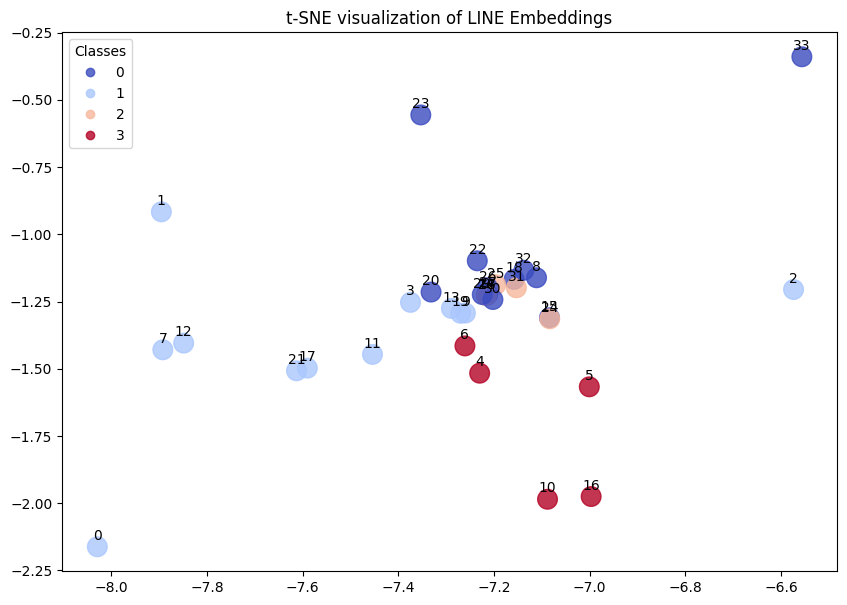

In [10]:
# 4. TSNE Visualization
def visualize_line_embeddings(model, graph):
    model.eval()
    embeddings = model.nodes_embeddings.weight.cpu().detach().numpy()

    tsne = TSNE(n_components=2, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)

    labels = [graph.nodes[node]["class"] for node in graph.nodes]

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=labels, cmap='coolwarm', s=200, alpha=0.8)
    
    for i, node in enumerate(graph.nodes()):
        plt.annotate(str(node), (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                     textcoords="offset points", xytext=(0, 5), ha='center', fontsize=10)

    plt.legend(*scatter.legend_elements(), title="Classes")
    plt.title("t-SNE visualization of LINE Embeddings")
    plt.show()

visualize_line_embeddings(line_model, karate_graph)
